# LSTM Temporal Model

This notebook implements an LSTM model for Taxi-Out prediction.


Dataset shape : (339013, 26)
   month  day_of_month  scheduled_departure_time  scheduled_arrival_time  \
0      1             4                       400                     479   
1      1             4                       360                     434   
2      1             4                       400                     545   
3      1             4                       375                     488   
4      1             4                       440                     514   

  unique_carrier  flight_number  scheduled_elapsed_time  departure_delay  \
0             XE           2348                    79.0             -7.0   
1             YV           7331                   134.0             15.0   
2             OH           4999                   145.0             50.0   
3             OH           5303                   113.0             15.0   
4             OO           5873                   134.0              0.0   

  origin dest  ...  day  day_of_week_num  is_weekend  dep

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - loss: 0.6638 - mae: 0.5062 - val_loss: 0.7593 - val_mae: 0.5200 - learning_rate: 0.0010
Epoch 2/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: 0.6536 - mae: 0.5014 - val_loss: 0.7469 - val_mae: 0.5215 - learning_rate: 0.0010
Epoch 3/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - loss: 0.6515 - mae: 0.4998 - val_loss: 0.7502 - val_mae: 0.5060 - learning_rate: 0.0010
Epoch 4/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - loss: 0.6474 - mae: 0.4987 - val_loss: 0.7606 - val_mae: 0.5293 - learning_rate: 0.0010
Epoch 5/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - loss: 0.6453 - mae: 0.4972 - val_loss: 0.7425 - val_mae: 0.5176 - learning_rate: 0.0010
Epoch 6/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 61s 8ms/step - loss: 0.6434 - mae: 0.4968 - val_loss: 0.7418 - val_mae: 0.5085 - learning_rate: 0.0010
Epoch 7/30
7415/7415 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step - loss: 0.6404 - mae: 0.4959 - val_loss: 0.7497 - val_mae: 0.5139 - learnin

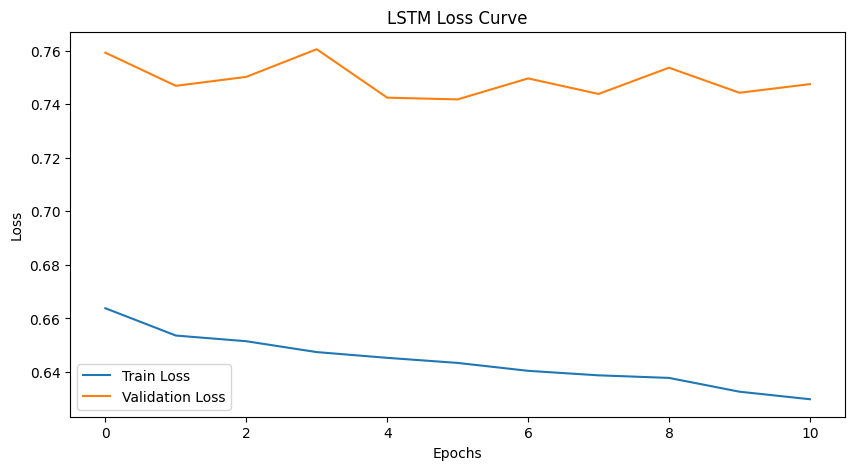

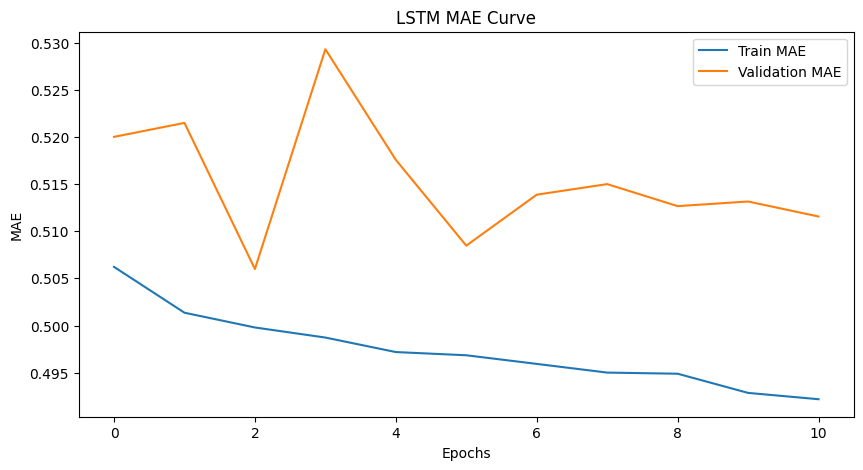


Model saved successfully ✔


In [ ]:
# ============================================================
# LSTM — TAXI-OUT PREDICTION
# WITH METRICS IN REAL MINUTES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_parquet("../data/featured_data.parquet")

print("Dataset shape :", df.shape)
print(df.head())


# ============================================================
# BASIC CLEANING
# ============================================================

delay_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

# keep only existing columns
delay_cols = [col for col in delay_cols if col in df.columns]

# fill missing values
df[delay_cols] = df[delay_cols].fillna(0)

# remove remaining NaN
df = df.dropna()

print("\nAfter cleaning :", df.shape)


# ============================================================
# CHRONOLOGICAL ORDER
# ============================================================

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("\nSorted chronologically ✔")


# ============================================================
# FEATURE SELECTION
# ============================================================

# IMPORTANT:
# Here we predict TAXI-OUT

target_col = "taxi_out"

features = [
    target_col,
    "scheduled_elapsed_time",
    "departure_hour",
    "airport_traffic",
    "carrier_traffic",
    "is_peak_hour"
]

# keep only existing columns
features = [col for col in features if col in df.columns]

data = df[features]

print("\nSelected features:")
print(features)

print(data.head())


# ============================================================
# SCALING
# ============================================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

# IMPORTANT:
# save scaler information for inverse transform

target_mean = scaler.mean_[0]
target_std = scaler.scale_[0]

print("\nScaling completed ✔")


# ============================================================
# CREATE SEQUENCES
# ============================================================

SEQ_LENGTH = 10

X = []
y = []

for i in range(SEQ_LENGTH, len(scaled_data)):

    # previous 10 flights
    X.append(
        scaled_data[i - SEQ_LENGTH:i]
    )

    # target taxi_out
    y.append(
        scaled_data[i][0]
    )

X = np.array(X)
y = np.array(y)

print("\nSequences created ✔")
print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

# train
X_train = X[:train_size]
y_train = y[:train_size]

# validation
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

# test
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("\nSplit completed ✔")

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# ============================================================
# LSTM MODEL
# ============================================================

model = Sequential([

    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(
        64,
        return_sequences=False
    ),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dense(1)

])

model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

print("\nModel Summary")
model.summary()


# ============================================================
# CALLBACKS
# ============================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

lr_scheduler = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    verbose=1

)


# ============================================================
# TRAINING
# ============================================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=30,

    batch_size=32,

    callbacks=[early_stop, lr_scheduler],

    verbose=1

)


# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# CONVERT BACK TO REAL MINUTES
# ============================================================

y_test_real = y_test * target_std + target_mean

y_pred_real = (
    y_pred.flatten() * target_std
    + target_mean
)


# ============================================================
# EVALUATION IN REAL MINUTES
# ============================================================

mae = mean_absolute_error(
    y_test_real,
    y_pred_real
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_real,
        y_pred_real
    )
)

r2 = r2_score(
    y_test_real,
    y_pred_real
)

print("\n==========================")
print("LSTM — TAXI OUT RESULTS")
print("==========================")

print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R2   : {r2:.4f}")


# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Loss Curve")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()


# ============================================================
# MAE CURVE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["mae"],
    label="Train MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title("LSTM MAE Curve")

plt.xlabel("Epochs")

plt.ylabel("MAE")

plt.legend()

plt.show()


# ============================================================
# SAVE MODEL
# ============================================================

model.save("../models/lstm_model.keras")

print("\nModel saved successfully ")